<a href="https://colab.research.google.com/github/Viera1624/TelecomX_LATAM/blob/main/telecomx_latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Trello del desafío](https://trello.com/b/Va6JwjjL/telecomxlatam)

#📌 Extracción

In [64]:
import pandas as pd

In [65]:
datos_clientes = pd.read_json('/content/TelecomX_Data.json')
datos_clientes.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##Normalizando Json

In [66]:
def normalizar_json(columna):
  df_norm = pd.json_normalize(datos_clientes[columna])

  return df_norm

customer = normalizar_json('customer')
phone = normalizar_json('phone')
internet = normalizar_json('internet')
account = normalizar_json('account')


In [67]:
datos_clientes_norm = pd.concat([datos_clientes[['customerID', 'Churn']],
                                 customer, phone, internet, account],
                                axis=1)
datos_clientes_norm

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

##Verificando si hay valores nulos, duplicados o errores de formato

In [68]:
datos_clientes_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [69]:
datos_clientes_norm.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


Los IDs de cliente son valores únicos, por lo que no debería haber un ID presente más de una vez en nuestros registros

In [70]:
x =datos_clientes_norm['customerID'].unique()

In [71]:
len(x)

7267

##Normalizando las columnaas

###Renombrar las columnaas

In [72]:
columnas = list(datos_clientes_norm.columns)

columnas_nuevas = ['ID_Cliente','Retirado','Genero','Mayor_65_Años','Tiene_Pareja','Dependientes',
                    'Meses_De_Contrato','Servicio_Telefonico','Multiples_Lineas','Servicio_Internet','Seguridad_En_linea',
                    'Respaldo_En_linea','Proteccion_Del_Dispositivo','Soporte_Tecnico','Television_Por_Cable','Streaming_Peliculas',
                    'Tipo_De_Contrato', 'Factura_En_Linea','Metodo_De_Pago', 'Total_Por_Mes',
                    'Total_Gastado']

renombrar = dict(zip(columnas,columnas_nuevas))

In [73]:
datos_clientes_norm.rename(columns=renombrar, inplace=True)
datos_clientes_norm.head(1)

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Respaldo_En_linea,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3


##Transformando datos numéricos

Alintentar transformar el tipo de datos de la columna Total_Gastado a float encontramos que hay espacios entre los registros, vamos a verificar

In [74]:
datos_clientes_norm[datos_clientes_norm['Total_Gastado'].str.contains('\ ', na= False)]

<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-4215343052.py:1: SyntaxWarning: invalid escape sequence '\ '
  datos_clientes_norm[datos_clientes_norm['Total_Gastado'].str.contains('\ ', na= False)]


,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Respaldo_En_linea,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


Una vez encontrados los registros que tienen espacios, podemos observar que coinciden con el numero 0(cero) en la columna Meses_De_Contrato, esto puede indicar que son clientes nuevos y por lo tanto, no han acumulado un cargo total. Vamos a verificar si hay más clientes nuevos

In [75]:
datos_clientes_norm.query('Meses_De_Contrato == 0')

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Respaldo_En_linea,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


los resultados obtenidos coinciden con ceros en la columna Meses_De_Contrato y espacios en Total_Gastado, procedemos entonces a reemplazar espacios por ceros y realizar la respectiva transformación

In [76]:
datos_clientes_norm['Total_Gastado']= datos_clientes_norm['Total_Gastado'].replace('\ ', '0', regex=True)


<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-3318985259.py:1: SyntaxWarning: invalid escape sequence '\ '
  datos_clientes_norm['Total_Gastado']= datos_clientes_norm['Total_Gastado'].replace('\ ', '0', regex=True)


In [77]:
import numpy as np
datos_clientes_norm['Total_Gastado']= datos_clientes_norm['Total_Gastado'].astype(np.float64)

Ahora, tenemos una serie de columnas con valores de "Yes" y "No", pero para este análisis nos resultaría más fácil trabajar con 0 para "No" y 1 para "Yes", así que vamos a reemplazar estos valores creando una lista con dichas columnas que queremos transformar de str a int64

In [78]:
transformar = ['Retirado','Tiene_Pareja','Dependientes',
               'Servicio_Telefonico','Multiples_Lineas','Seguridad_En_linea',
               'Respaldo_En_linea','Proteccion_Del_Dispositivo','Soporte_Tecnico','Television_Por_Cable','Streaming_Peliculas',
               'Factura_En_Linea']

Verificamos los valores únicos en las columnasde nuestra lista para identificar las posibles complicaciones (Valores distintos a "Yes" o "No") al momento de realizar la transformación

In [79]:
for columna in datos_clientes_norm[transformar]:
    print(f"Valores unicos para la columna '{columna}':")
    print(datos_clientes_norm[columna].unique())
    print("\n")

Valores unicos para la columna 'Retirado':
['No' 'Yes' '']


Valores unicos para la columna 'Tiene_Pareja':
['Yes' 'No']


Valores unicos para la columna 'Dependientes':
['Yes' 'No']


Valores unicos para la columna 'Servicio_Telefonico':
['Yes' 'No']


Valores unicos para la columna 'Multiples_Lineas':
['No' 'Yes' 'No phone service']


Valores unicos para la columna 'Seguridad_En_linea':
['No' 'Yes' 'No internet service']


Valores unicos para la columna 'Respaldo_En_linea':
['Yes' 'No' 'No internet service']


Valores unicos para la columna 'Proteccion_Del_Dispositivo':
['No' 'Yes' 'No internet service']


Valores unicos para la columna 'Soporte_Tecnico':
['Yes' 'No' 'No internet service']


Valores unicos para la columna 'Television_Por_Cable':
['Yes' 'No' 'No internet service']


Valores unicos para la columna 'Streaming_Peliculas':
['No' 'Yes' 'No internet service']


Valores unicos para la columna 'Factura_En_Linea':
['Yes' 'No']




Como podemos observar, hay columnas que tienen cadenas vacías (''), entre otras como 'No internet service' y 'No phone service', tenemos que reemplazar también estos valores por 0 para poder realizar nuestra transformación

In [80]:
#Creamos un diccionario con los valores a reemplazar
reemplazar = {'': '0', 'No phone service': '0', 'No internet service': '0', 'Yes': '1', 'No': '0'}

#Reemplazamos los valores con un replace() dentro de un lazo for
for columna in datos_clientes_norm[transformar]:
  datos_clientes_norm[transformar] = datos_clientes_norm[transformar].replace(reemplazar)


In [81]:
for columna in datos_clientes_norm[transformar]:
    print(f"Valores unicos para la columna '{columna}':")
    print(datos_clientes_norm[columna].unique())
    print("\n")

Valores unicos para la columna 'Retirado':
['0' '1']


Valores unicos para la columna 'Tiene_Pareja':
['1' '0']


Valores unicos para la columna 'Dependientes':
['1' '0']


Valores unicos para la columna 'Servicio_Telefonico':
['1' '0']


Valores unicos para la columna 'Multiples_Lineas':
['0' '1']


Valores unicos para la columna 'Seguridad_En_linea':
['0' '1']


Valores unicos para la columna 'Respaldo_En_linea':
['1' '0']


Valores unicos para la columna 'Proteccion_Del_Dispositivo':
['0' '1']


Valores unicos para la columna 'Soporte_Tecnico':
['1' '0']


Valores unicos para la columna 'Television_Por_Cable':
['1' '0']


Valores unicos para la columna 'Streaming_Peliculas':
['0' '1']


Valores unicos para la columna 'Factura_En_Linea':
['1' '0']




In [82]:
datos_clientes_norm[transformar] = datos_clientes_norm[transformar].astype(np.int64)

In [83]:
datos_clientes_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID_Cliente                  7267 non-null   object 
 1   Retirado                    7267 non-null   int64  
 2   Genero                      7267 non-null   object 
 3   Mayor_65_Años               7267 non-null   int64  
 4   Tiene_Pareja                7267 non-null   int64  
 5   Dependientes                7267 non-null   int64  
 6   Meses_De_Contrato           7267 non-null   int64  
 7   Servicio_Telefonico         7267 non-null   int64  
 8   Multiples_Lineas            7267 non-null   int64  
 9   Servicio_Internet           7267 non-null   object 
 10  Seguridad_En_linea          7267 non-null   int64  
 11  Respaldo_En_linea           7267 non-null   int64  
 12  Proteccion_Del_Dispositivo  7267 non-null   int64  
 13  Soporte_Tecnico             7267 

##Creacion de columna Cuentas_Diarias

In [84]:
datos_clientes_norm['Cuentas_Diarias'] = (datos_clientes_norm['Total_Por_Mes']/30).round(2)


In [85]:
datos_clientes_norm.head(2)

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,2.00


#📊 Carga y análisis

##Análisis descriptivo

In [86]:
datos_clientes_norm.describe()

,Retirado,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Seguridad_En_linea,Respaldo_En_linea,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Factura_En_Linea,Total_Por_Mes,Total_Gastado,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.157292
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


##Distribución de evasión

In [87]:
evasion = datos_clientes_norm['Retirado'].value_counts()
evasion

,count
Retirado,
0,5398
1,1869


###Visualización de evasiones

In [88]:
import matplotlib.pyplot as plt

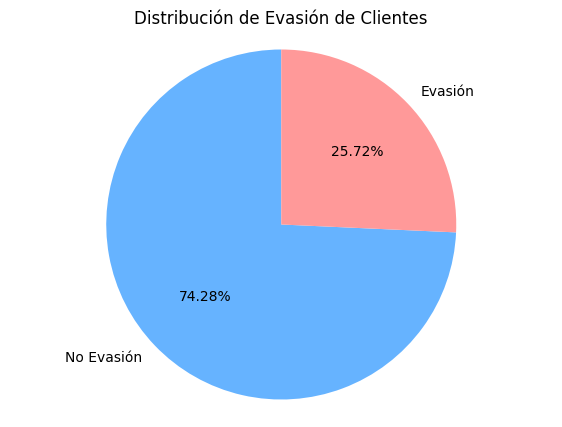

In [89]:
fig, ax = plt.subplots(figsize=(7,5))

etiquetas = ['No Evasión', 'Evasión']
#tamaños = [evasion[0], evasion[1]]  Esta opcion devuelve los conteos de los indices del pandas Series
colores = ['#66b3ff','#ff9999']

ax.pie(evasion.values, labels=etiquetas, autopct='%1.2f%%', startangle=90, colors=colores)
ax.axis('equal') # Una relación de aspecto equal asegura que el gráfico se dibujecomo un circulo

plt.title('Distribución de Evasión de Clientes')
plt.show()

##Recuento de evasión por variables categóricas

In [90]:
datos_clientes_norm.head(1)

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.19


Vamos a explorar un poco los datos para conocer cuáles son las variables categóricas más relevantes para el análisis. Empezaremos por algo sencillo, como contar la columna Genero

In [91]:
datos_clientes_norm['Genero'].value_counts()

,count
Genero,
Male,3675
Female,3592


No hay una diferencia significativa entre ambos géneros, probemos entonces con una agrupación para saber si hay más presencia de alguno de los dos en las columas `Tipo_De_Contrato` y `Metodo_De_Pago`. Vamos a desapilar también la columna Genero usando unstack() para tener una mejor visualización.

In [124]:
datos_clientes_norm.groupby(['Tipo_De_Contrato','Metodo_De_Pago', ])['Genero'].value_counts().unstack(level='Genero')


Genero                                      Female  Male
Tipo_De_Contrato Metodo_De_Pago                         
Month-to-month   Bank transfer (automatic)     320   288
                 Credit card (automatic)       276   281
                 Electronic check              955   960
                 Mailed check                  431   494
One year         Bank transfer (automatic)     199   202
                 Credit card (automatic)       205   208
                 Electronic check              167   192
                 Mailed check                  169   177
Two year         Bank transfer (automatic)     294   286
                 Credit card (automatic)       293   305
                 Electronic check               83    88
                 Mailed check                  200   194

Observemos que en Tipo_De_contrato "Month-to-month" (mes a mes) y Metodo_De_Pago "Electronic check" tenemos una cantidad significativa de Male y Female (Masculino y Femenino), por lo que estas dos columnas podrían ser determinantes en nuestro análisis.

Realicemos ahora una agrupación incluyendo las columnas anteriores, contando finalmente la evasión por cada combinación de estas categorias

In [125]:
evasion_por_categorias = datos_clientes_norm.groupby(['Genero', 'Tipo_De_Contrato', 'Metodo_De_Pago'])['Retirado'].value_counts()
evasion_por_categorias

Genero  Tipo_De_Contrato  Metodo_De_Pago             Retirado
Female  Month-to-month    Bank transfer (automatic)  0           208
                                                     1           112
                          Credit card (automatic)    0           173
                                                     1           103
                          Electronic check           1           492
                                                     0           463
                          Mailed check               0           296
                                                     1           135
        One year          Bank transfer (automatic)  0           182
                                                     1            17
                          Credit card (automatic)    0           183
                                                     1            22
                          Electronic check           0           144
                                                     1            23
                          Mailed check               0           156
                                                     1            13
        Two year          Bank transfer (automatic)  0           287
                                                     1             7
                          Credit card (automatic)    0           287
                                                     1             6
                          Electronic check           0            76
                                                     1             7
                          Mailed check               0           198
                                                     1             2
Male    Month-to-month    Bank transfer (automatic)  0           199
                                                     1            89
                          Credit card (automatic)    0           206
                                                     1            75
                          Electronic check           1           502
                                                     0           458
                          Mailed check               0           347
                                                     1           147
        One year          Bank transfer (automatic)  0           181
                                                     1            21
                          Credit card (automatic)    0           189
                                                     1            19
                          Electronic check           0           151
                                                     1            41
                          Mailed check               0           167
                                                     1            10
        Two year          Bank transfer (automatic)  0           274
                                                     1            12
                          Credit card (automatic)    0           298
                                                     1             7
                          Electronic check           0            82
                                                     1             6
                          Mailed check               0           193
                                                     1             1
Name: count, dtype: int64



###Pasos a seguir

1. Transformar la serie `evasion_por_categorias` en un DataFrame.
2. Reorganizar el nivel de índice 'Retirado' para crear columnas separadas para los conteos de 'No Evasión' (0) y 'Evasión' (1).
3. Calcular la tasa de evasión (porcentaje de 'Retirado' = 1) para cada combinación de 'Genero', 'Tipo_De_Contrato' y 'Metodo_De_Pago'.
4. Crear un gráfico de barras para visualizar las tasas de evasión, enfocándose en las variables categóricas clave y asegurando etiquetas y leyendas claras.
5. Proporcionar un resumen de las principales observaciones y patrones del análisis.

####Transformar la serie evasion_por_categorias en un dataFrame y desapilar la columna "Retirado"






In [115]:
df_evasion_por_categorias = evasion_por_categorias.unstack(level='Retirado')
df_evasion_por_categorias = df_evasion_por_categorias.reset_index()
df_evasion_por_categorias

Retirado,Genero,Mayor_65_Años,Tipo_De_Contrato,Metodo_De_Pago,0,1
0,Female,0,Month-to-month,Bank transfer (automatic),177.0,89.0
1,Female,0,Month-to-month,Credit card (automatic),144.0,77.0
2,Female,0,Month-to-month,Electronic check,350.0,340.0
3,Female,0,Month-to-month,Mailed check,278.0,115.0
4,Female,0,One year,Bank transfer (automatic),153.0,15.0
5,Female,0,One year,Credit card (automatic),161.0,15.0
6,Female,0,One year,Electronic check,115.0,17.0
7,Female,0,One year,Mailed check,148.0,12.0
8,Female,0,Two year,Bank transfer (automatic),256.0,6.0
9,Female,0,Two year,Credit card (automatic),259.0,4.0


Vamos a llamar al método info() para asegurarnos de que los tipos de datos sean correctos y no hayan valores nulos

In [116]:
df_evasion_por_categorias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Genero            48 non-null     object 
 1   Mayor_65_Años     48 non-null     int64  
 2   Tipo_De_Contrato  48 non-null     object 
 3   Metodo_De_Pago    48 non-null     object 
 4   0                 48 non-null     float64
 5   1                 44 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 2.4+ KB


Ahora calculamos la tasa de evasión (1) creando una nueva columna llamada Tasa_de_Evasion. También notamos que en ciertas combinaciones no hubieron retirados, por lo tanto de nuestro dataFrame df_evasion_por_categorias obtuvimos algunos NaN en la columna (1) que debemos manejar reemplazandolos por 0 (cero)

In [108]:
df_evasion_por_categorias = df_evasion_por_categorias.fillna(0)
df_evasion_por_categorias['Tasa_de_Evasion'] = (df_evasion_por_categorias[1] / (df_evasion_por_categorias[0] + df_evasion_por_categorias[1])) * 100
df_evasion_por_categorias.head()

,Genero,Mayor_65_Años,Tipo_De_Contrato,Metodo_De_Pago,0,1,Tasa_de_Evasion
0,Female,0,Month-to-month,Bank transfer (automatic),177.0,89.0,33.458647
1,Female,0,Month-to-month,Credit card (automatic),144.0,77.0,34.841629
2,Female,0,Month-to-month,Electronic check,350.0,340.0,49.275362
3,Female,0,Month-to-month,Mailed check,278.0,115.0,29.262087
4,Female,0,One year,Bank transfer (automatic),153.0,15.0,8.928571


## Visualizar Tasas de Evasión






El siguiente paso es visualizar las tasas de evasión calculadas. Utilizaremos seaborn.barplot para crear un gráfico de barras, representando 'Tipo_De_Contrato' en el eje x, 'Tasa_de_Evasion' en el eje y, y usando 'Metodo_De_Pago' como un matiz para diferenciar las barras. Esto ayudará a identificar patrones de deserción según el tipo de contrato y el método de pago.


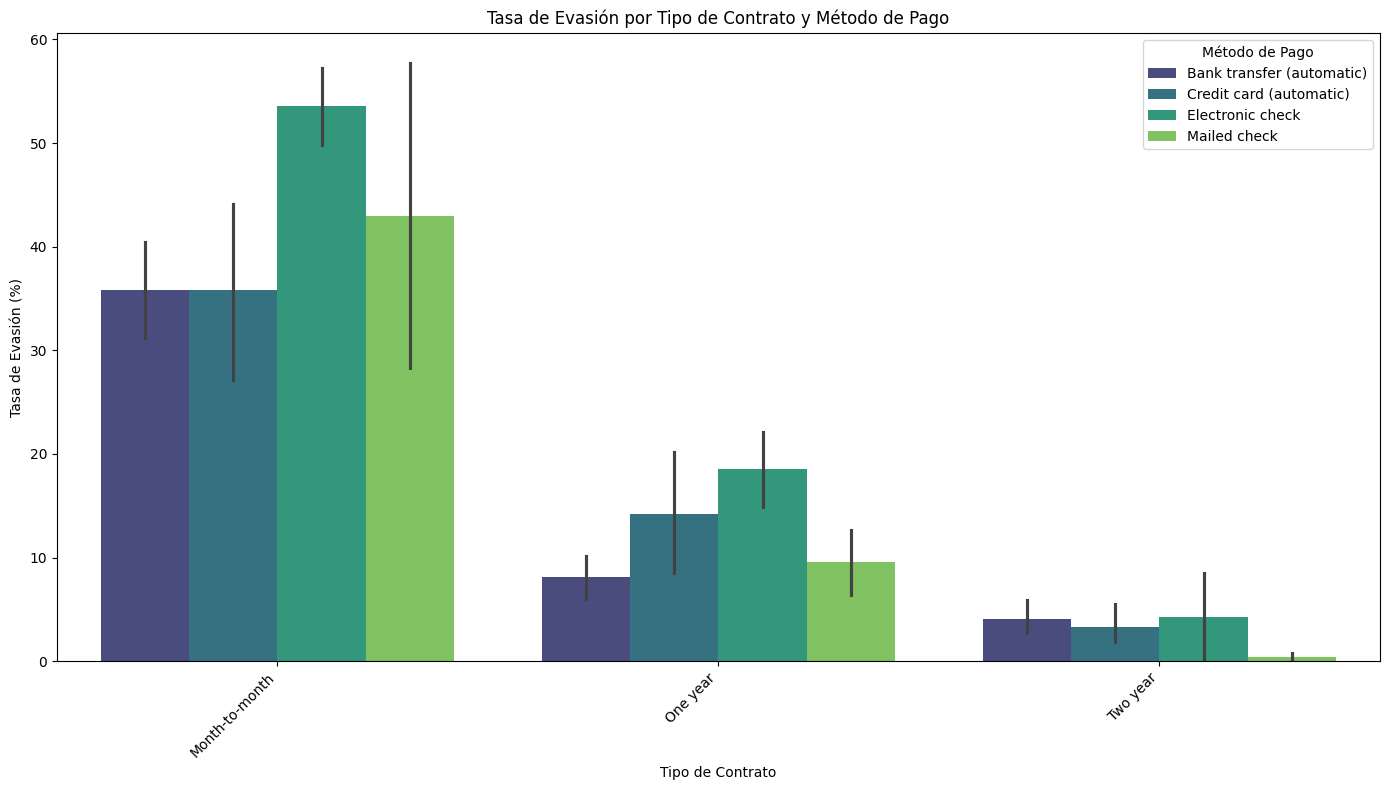

In [109]:
import seaborn as sns


plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_evasion_por_categorias,
    x='Tipo_De_Contrato',
    y='Tasa_de_Evasion',
    hue='Metodo_De_Pago',
    palette='viridis'
)
plt.title('Tasa de Evasión por Tipo de Contrato y Método de Pago')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Tasa de Evasión (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de Pago')
plt.tight_layout()
plt.show()

## Observaciones de la Tasa de Evasión por Tipo de Contrato y Método de Pago

El gráfico de barras muestra la tasa de evasión de clientes (`Retirado` = 1) para diferentes combinaciones de `Tipo_De_Contrato` y `Metodo_De_Pago`.

### Patrones Observados:

*   **Contrato Mes a Mes (Month-to-month):** Se observa consistentemente que los clientes con contratos mes a mes tienen una tasa de evasión significativamente más alta en comparación con otros tipos de contrato, independientemente del método de pago. Esto sugiere que la falta de un compromiso a largo plazo es un factor clave en la evasión.

*   **Método de Pago 'Electronic check':** Para los contratos mes a mes, el método de pago 'Electronic check' (cheque electrónico) muestra una de las tasas de evasión más altas. Esto podría indicar que los clientes que utilizan este método de pago en contratos cortos son más propensos a cancelar el servicio.

*   **Contratos de Uno y Dos Años (One year y Two year):** Los clientes con contratos de uno y dos años presentan tasas de evasión considerablemente más bajas en todas las categorías de métodos de pago. Esto refuerza la idea de que los contratos a largo plazo fomentan la lealtad y reducen la probabilidad de evasión.

*   **Métodos de Pago 'Bank transfer (automatic)' y 'Credit card (automatic)':** Estos métodos de pago tienden a tener tasas de evasión más bajas en general, especialmente en contratos de mayor duración, lo que sugiere una mayor estabilidad y menor probabilidad de cancelación por parte de los clientes que los utilizan.

*   **'Mailed check' (Cheque por correo):** Este método de pago muestra una tasa de evasión moderada, siendo más alta en contratos mes a mes y disminuyendo con contratos más largos.

### Conclusiones Preliminares:

1.  **Tipo de Contrato:** El tipo de contrato es un predictor muy fuerte de la evasión, siendo los contratos 'Month-to-month' los de mayor riesgo.
2.  **Método de Pago:** Dentro de los contratos a corto plazo, el 'Electronic check' es un método de pago asociado a una mayor evasión.
3.  **Lealtad:** Los clientes con contratos a largo plazo y aquellos que utilizan métodos de pago automáticos (transferencia bancaria o tarjeta de crédito) son los más estables y menos propensos a la evasión.

En resumen, la **duración del contrato** es el principal motor de la evasión, con los contratos mes a mes siendo un punto crítico. El **método de pago** es un factor secundario importante, especialmente en los contratos más cortos, donde 'Electronic check' indica un mayor riesgo.

#📄Informe final